In [1]:
!pip install yfinance statsmodels

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

In [3]:
ticker = "NPN.JO"
data = yf.download(ticker, start="2015-01-01", end="2024-12-31")

data.head()

/tmp/ipython-input-493/4254018683.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NPN.JO,NPN.JO,NPN.JO,NPN.JO,NPN.JO
Date,,,,,
2015-01-01,19031.970703,19031.970703,19031.970703,19031.970703,0
2015-01-02,19209.083984,19407.301662,18867.162736,18967.654880,3456193
2015-01-05,19003.957031,19567.962610,18957.855991,19219.006709,13635330
2015-01-06,19960.382812,19960.382812,19243.379934,19591.455336,17504973
2015-01-07,20726.244141,20814.174279,20035.495854,20173.545156,10389876


In [4]:
data['Return'] = np.log(data['Close'] / data['Close'].shift(1))
data = data.dropna()

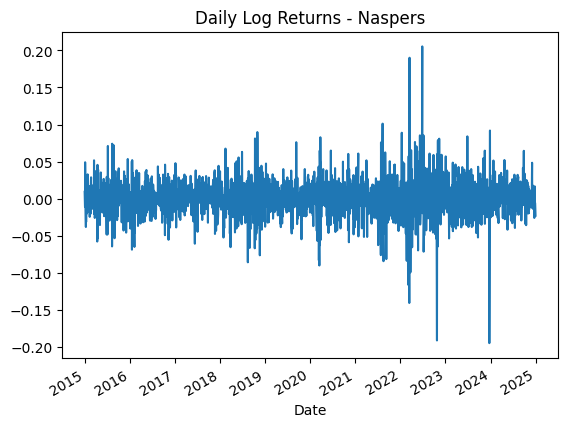

In [5]:
plt.figure()
data['Return'].plot()
plt.title("Daily Log Returns - Naspers")
plt.show()

Returns are stationary.

In [6]:
data['Return'].describe()

,Return
count,2525.000000
mean,0.000583
std,0.024174
min,-0.194758
25%,-0.011731
50%,0.000188
75%,0.012812
max,0.205305


Little evidence of predictable returns.


In [7]:
result = adfuller(data['Return'])
print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -17.898545732911906
p-value: 2.9593259401607546e-30


In [8]:
data['Lag_Return'] = data['Return'].shift(1)
data = data.dropna()

X = sm.add_constant(data['Lag_Return'])
model = sm.OLS(data['Return'], X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 Return   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.000
Method:                 Least Squares   F-statistic:                    0.4620
Date:                Sun, 01 Mar 2026   Prob (F-statistic):              0.497
Time:                        18:09:20   Log-Likelihood:                 5814.4
No. Observations:                2524   AIC:                        -1.162e+04
Df Residuals:                    2522   BIC:                        -1.161e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0006      0.000      1.221      0.2

Volatility clustering observed.

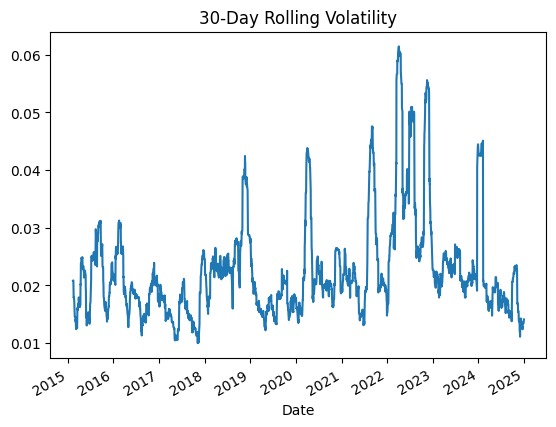

In [9]:
data['Volatility'] = data['Return'].rolling(30).std()

plt.figure()
data['Volatility'].plot()
plt.title("30-Day Rolling Volatility")
plt.show()

Risk fluctuates significantly over time.